In [1]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.utils import io
import random

models_path = os.path.abspath(os.path.join('..', 'models'))
sys.path.append(models_path)

from BKT.bkt_model import ModelBKT

random.seed(42)


In [2]:
with open('../data/preprocessed/skills_dict.json', 'r') as json_file:
    skills_dict = json.load(json_file)

In [3]:
results = []
results_with_forget = []

# Redirect tqdm's output to avoid interference
with tqdm(skills_dict.items(), desc="Processing skills") as pbar:
    for skill_id, user_answers in pbar:
        # Suppress output during fit
        with io.capture_output():
            random.shuffle(user_answers)

            # Define the split ratio
            train_size = int(0.8 * len(user_answers))  # 80% for training, 20% for testing

            # Split the shuffled list into train and test
            train_answers = user_answers[:train_size]
            test_answers = user_answers[train_size:]

            model = ModelBKT(skill_id, train_answers)
            model.fit()
            auc = model.evaluate(test_answers)  # Evaluate model
            results.append({"skill_id": skill_id, "auc": auc})

            model_with_forget = ModelBKT(skill_id, train_answers, allow_forget=True)
            model_with_forget.fit()
            auc_with_forget = model_with_forget.evaluate(test_answers)  # Evaluate model
            results_with_forget.append({"skill_id": skill_id, "auc": auc_with_forget})


Processing skills: 100%|██████████| 86/86 [00:41<00:00,  2.06it/s]


Total number of valid skills: 86


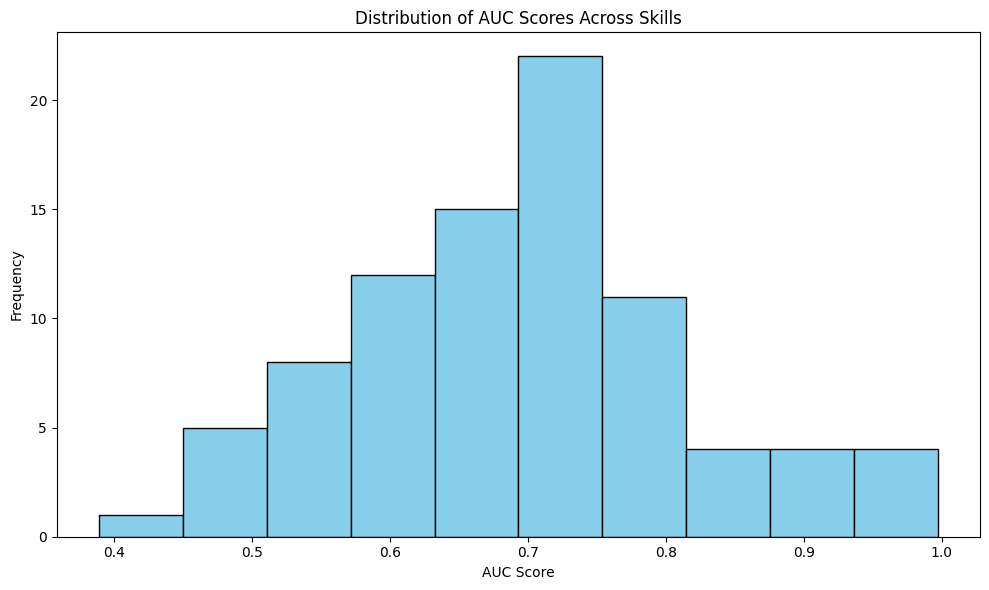

Average AUC across all skills: 0.6960


In [4]:
# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Print the total number of valid skills
print(f"Total number of valid skills: {len(results_df)}")

# Plot a histogram of AUC scores
plt.figure(figsize=(10, 6))
plt.hist(results_df["auc"], bins=10, color="skyblue", edgecolor="black")
plt.xlabel("AUC Score")
plt.ylabel("Frequency")
plt.title("Distribution of AUC Scores Across Skills")
plt.tight_layout()
plt.show()

# Report the average AUC
average_auc = results_df["auc"].mean()
print(f"Average AUC across all skills: {average_auc:.4f}")

![AUC Scores from the Stanford Paper](./../pictures/AUC_results.png)


Our average AUC score (0.696) is above the Marginal 0.62 and managed to surpass the 0.67 mentioned in the paper, probably due to the more extensive data cleaning process.

Total number of valid skills: 86


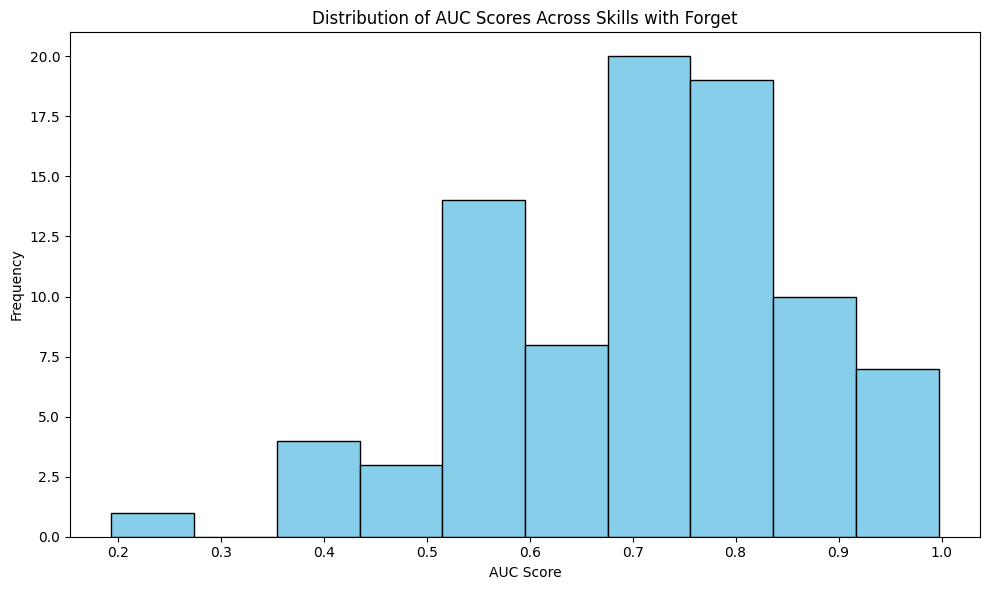

Average AUC across all skills with forget: 0.7101


In [5]:
# Convert results to a DataFrame
results_with_forget_df = pd.DataFrame(results_with_forget)

# Print the total number of valid skills
print(f"Total number of valid skills: {len(results_with_forget_df)}")

# Plot a histogram of AUC scores
plt.figure(figsize=(10, 6))
plt.hist(results_with_forget_df["auc"], bins=10, color="skyblue", edgecolor="black")
plt.xlabel("AUC Score")
plt.ylabel("Frequency")
plt.title("Distribution of AUC Scores Across Skills with Forget")
plt.tight_layout()
plt.show()

# Report the average AUC
average_auc = results_with_forget_df["auc"].mean()
print(f"Average AUC across all skills with forget: {average_auc:.4f}")


AUC further improved to 0.710 if allowing to forget.